<a href="https://colab.research.google.com/github/darrickpang/Email/blob/master/Trajectory_prediction.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [33]:
pip install nuscenes-devkit torch numpy matplotlib tqdm

In [34]:
# Mount the Google Drive to use content

from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [35]:
from nuscenes.nuscenes import NuScenes

DATA_ROOT = "/content/drive/MyDrive/v1.0-mini"  # adjust if local
nusc = NuScenes(version='v1.0-mini', dataroot=DATA_ROOT, verbose=True)

print("Number of scenes:", len(nusc.scene))

Loading NuScenes tables for version v1.0-mini...
23 category,
8 attribute,
4 visibility,
911 instance,
12 sensor,
120 calibrated_sensor,
31206 ego_pose,
8 log,
10 scene,
404 sample,
31206 sample_data,
18538 sample_annotation,
4 map,
Done loading in 1.114 seconds.
Reverse indexing ...
Done reverse indexing in 0.2 seconds.
Number of scenes: 10


We will be using
```python
def get_vehicle_trajectory(nusc, instance_token):
```
to extract the vehicle trajectory of a single vehicle instance using the time-ordered (x, y) trajectory.

In [36]:
def get_vehicle_trajectory(nusc, instance_token):
    positions = []

    for ann in nusc.sample_annotation:
        if ann["instance_token"] == instance_token:
            x, y, _ = ann["translation"]
            positions.append((ann["timestamp"], x, y))

    positions.sort(key=lambda x: x[0])
    return positions

This selects a single scene to:
1. inspect annotation structure
2. confirm vehicle category names
3. obtain an instance_token for testing

In [37]:
scene = nusc.scene[0]   # first scene in mini
print(scene["name"])

scene-0061


In [38]:
sample_token = scene["first_sample_token"]
sample = nusc.get("sample", sample_token)

In [39]:
vehicle_ann = None

for ann_token in sample["anns"]:
    ann = nusc.get("sample_annotation", ann_token)
    if ann["category_name"].startswith("vehicle"):
        vehicle_ann = ann
        break

vehicle_ann

{'token': '924ee6ac1fed440a9d9e3720aac635a0',
 'sample_token': 'ca9a282c9e77460f8360f564131a8af5',
 'instance_token': 'bd26c2cdb22d4bb1834e808c89128898',
 'visibility_token': '3',
 'attribute_tokens': ['c3246a1e22a14fcb878aa61e69ae3329'],
 'translation': [353.794, 1132.355, 0.602],
 'size': [2.011, 4.633, 1.573],
 'rotation': [0.9797276292877292, 0.0, 0.0, -0.20033415188191459],
 'prev': '',
 'next': 'f0cbd9dbafd74e20bcf6dd0357c97f59',
 'num_lidar_pts': 5,
 'num_radar_pts': 0,
 'category_name': 'vehicle.car'}

In [40]:
instance_token = vehicle_ann["instance_token"]
print(instance_token)

bd26c2cdb22d4bb1834e808c89128898


We are plotting the trajectory of a vehicle in an (x, y) diagram

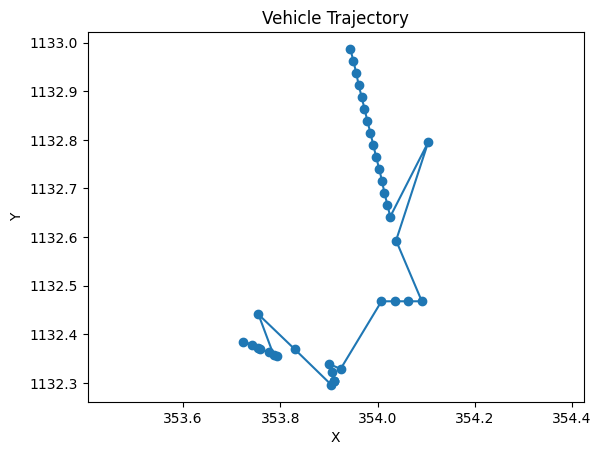

In [41]:
import matplotlib.pyplot as plt

# Redefine the function with the fix
def get_vehicle_trajectory(nusc, instance_token):
    positions = []

    for ann_data in nusc.sample_annotation:
        if ann_data["instance_token"] == instance_token:
            x, y, _ = ann_data["translation"]
            # Get the sample related to this annotation to retrieve the timestamp
            sample_record = nusc.get('sample', ann_data['sample_token'])
            timestamp = sample_record['timestamp']
            positions.append((timestamp, x, y))

    positions.sort(key=lambda x: x[0])
    return positions

traj = get_vehicle_trajectory(nusc, instance_token)

xs = [p[1] for p in traj]
ys = [p[2] for p in traj]

plt.plot(xs, ys, marker="o")
plt.title("Vehicle Trajectory")
plt.xlabel("X")
plt.ylabel("Y")
plt.axis("equal")
plt.show()

In [42]:
# traj_lengths = []

# for inst in vehicle_instances:
#     traj = get_vehicle_trajectory(nusc, inst["token"])
#     traj_lengths.append(len(traj))

# import numpy as np
# print("Min:", np.min(traj_lengths))
# print("Mean:", np.mean(traj_lengths))
# print("Max:", np.max(traj_lengths))

This is window sizes that will determine how much we want to use as input (past) and output (future).

In addition, we have
```python
def create_trajectory_samples(traj):
```
so we can convert raw trajectories into supervised learning data

In [43]:
import numpy as np

# From above, we see that the max is 41 frames so we don't want len(all_samples) = 0
PAST_LEN = 8     # 0.8 seconds
FUTURE_LEN = 12   # 1.2 seconds

def create_trajectory_samples(traj):
    """
    traj: list of (timestamp, x, y)
    returns: list of (past, future)
    """
    samples = []
    traj = sorted(traj, key=lambda x: x[0])

    coords = np.array([[p[1], p[2]] for p in traj])

    for i in range(len(coords) - PAST_LEN - FUTURE_LEN):
        past = coords[i : i + PAST_LEN]
        future = coords[i + PAST_LEN : i + PAST_LEN + FUTURE_LEN]
        samples.append((past, future))

    return samples

We want to collect vehicle instances so we can iterate over all tracked objects and filters vehicle instances only by resolving category tokens. This ensures the dataset contains only relevant road agents.

In [44]:
vehicle_instances = []

for inst in nusc.instance:
    category = nusc.get("category", inst["category_token"])
    if category["name"].startswith("vehicle"):
        vehicle_instances.append(inst)

len(vehicle_instances)

476

In [45]:
all_samples = []

for inst in vehicle_instances:
    traj = get_vehicle_trajectory(nusc, inst["token"])

    # 🚨 Filter short tracks
    if len(traj) < PAST_LEN + FUTURE_LEN:
        continue

    samples = create_trajectory_samples(traj)
    all_samples.extend(samples)

len(all_samples)

2532

We need to normalize trajectories to transform trajectories into an ego-relative frame by subtracting the last past point. This removes absolute position bias and helps the model learn motion patterns instead of location.

In [46]:
def normalize(past, future):
    origin = past[-1]
    return past - origin, future - origin

We use
```python
class TrajectoryDataset(Dataset):
```
to wrap the trajectory samples into a PyTorch-compatible dataset so they can be:
1. batched,
2. shuffled,
3. loaded efficiently during training.

In [47]:
import torch
from torch.utils.data import Dataset

class TrajectoryDataset(Dataset):
    def __init__(self, samples):
        self.data = []
        for past, future in samples:
            p, f = normalize(past, future)
            self.data.append((p, f))

    def __len__(self):
        return len(self.data)

    def __getitem__(self, idx):
        past, future = self.data[idx]
        return (
            torch.tensor(past, dtype=torch.float32),
            torch.tensor(future, dtype=torch.float32)
        )

In [48]:
from torch.utils.data import DataLoader

dataset = TrajectoryDataset(all_samples)
loader = DataLoader(dataset, batch_size=64, shuffle=True)

Split data into training and validation. 80 percent to 20 percent.

In [49]:
from torch.utils.data import random_split

dataset = TrajectoryDataset(all_samples)

train_size = int(0.8 * len(dataset))
val_size = len(dataset) - train_size

train_ds, val_ds = random_split(dataset, [train_size, val_size])

train_loader = DataLoader(train_ds, batch_size=64, shuffle=True)
val_loader = DataLoader(val_ds, batch_size=64, shuffle=False)

This step defines a sequence model that:
1. encodes past motion using an LSTM,
2. predicts the final future position (x, y).

This is a standard baseline for trajectory prediction.

In [50]:
import torch.nn as nn

class LSTMPredictor(nn.Module):
    def __init__(self, input_dim=2, hidden_dim=64, num_layers=1):
        super().__init__()
        self.lstm = nn.LSTM(input_dim, hidden_dim, num_layers, batch_first=True)
        self.fc = nn.Linear(hidden_dim, 2)  # predict x, y

    def forward(self, past):
        # past: [B, T_past, 2]
        _, (h_n, _) = self.lstm(past)
        h = h_n[-1]                     # [B, hidden_dim]
        future = self.fc(h)             # [B, 2]
        return future

This is the training setup where we configure:
1. loss function (mean squared error),
2. optimizer (Adam),
3. learning rate.

This defines how the model learns.

In [51]:
device = "cuda" if torch.cuda.is_available() else "cpu"

model = LSTMPredictor().to(device)
criterion = nn.MSELoss()
optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)

Training loop

In [52]:
EPOCHS = 20

for epoch in range(EPOCHS):
    model.train()
    train_loss = 0

    for past, future in train_loader:
        past = past.to(device)
        future = future.to(device)

        target = future[:, -1]  # final future position

        pred = model(past)
        loss = criterion(pred, target)

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        train_loss += loss.item()

    print(f"Epoch {epoch+1:02d} | Train Loss: {train_loss / len(train_loader):.4f}")

Epoch 01 | Train Loss: 305.4235
Epoch 02 | Train Loss: 289.7974
Epoch 03 | Train Loss: 261.3303
Epoch 04 | Train Loss: 243.9168
Epoch 05 | Train Loss: 226.5934
Epoch 06 | Train Loss: 210.6379
Epoch 07 | Train Loss: 195.9524
Epoch 08 | Train Loss: 182.3708
Epoch 09 | Train Loss: 171.4392
Epoch 10 | Train Loss: 161.5032
Epoch 11 | Train Loss: 153.8047
Epoch 12 | Train Loss: 144.5811
Epoch 13 | Train Loss: 136.8921
Epoch 14 | Train Loss: 128.7209
Epoch 15 | Train Loss: 121.3261
Epoch 16 | Train Loss: 113.4897
Epoch 17 | Train Loss: 108.0286
Epoch 18 | Train Loss: 102.2148
Epoch 19 | Train Loss: 96.0377
Epoch 20 | Train Loss: 90.5019


This is the evaluation metric to calculate the Final Displacement Error (FDE), a standard AV metric measuring distance between predicted and true final positions.

This directly measures prediction accuracy.

In [53]:
def compute_fde(pred, gt):
    return torch.norm(pred - gt, dim=1).mean().item()

In [54]:
model.eval()
fde_total = 0

with torch.no_grad():
    for past, future in val_loader:
        past = past.to(device)
        future = future.to(device)

        gt = future[:, -1]
        pred = model(past)

        fde_total += compute_fde(pred, gt)

print("Validation FDE:", fde_total / len(val_loader))

Validation FDE: 5.214613169431686


Plot

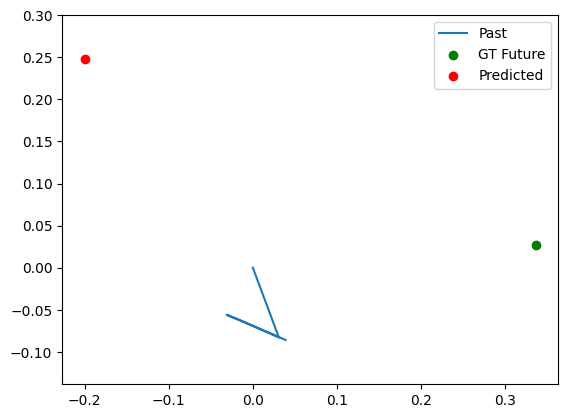

In [56]:
past, future = dataset[0]
past = past.unsqueeze(0).to(device)
pred = model(past).cpu().detach().numpy()[0]

import matplotlib.pyplot as plt

plt.plot(past[0,:,0].cpu(), past[0,:,1].cpu(), label="Past")
plt.scatter(future[-1,0], future[-1,1], label="GT Future", c="green")
plt.scatter(pred[0], pred[1], label="Predicted", c="red")
plt.legend()
plt.axis("equal")
plt.show()